In [1]:
import sklearn  # No real standard for importing as we don't use the entire module directly.
import pandas as pd

In [2]:
california_housing = pd.read_csv("california_housing.csv") # load the dataset

california_housing.head() # Take a look at the data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [3]:
california_housing.info() # Check the details of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [ ]:
sum(california_housing.total_bedrooms.isnull()) # Calculate the number of missing values

207

In [6]:
california_housing.total_bedrooms.describe()

count    20433.000000
mean       537.870553
std        421.385070
min          1.000000
25%        296.000000
50%        435.000000
75%        647.000000
max       6445.000000
Name: total_bedrooms, dtype: float64

In [11]:
# Let's first plot the total_bedrooms column to understand the distribution of values
clean_total_bedrooms = california_housing[~california_housing.total_bedrooms.isnull()].total_bedrooms # select the rows with a value in 'total_bedrooms' column and get the column itself after removing missing values
clean_total_bedrooms.info()

<class 'pandas.core.series.Series'>
Index: 20433 entries, 0 to 20639
Series name: total_bedrooms
Non-Null Count  Dtype  
--------------  -----  
20433 non-null  float64
dtypes: float64(1)
memory usage: 319.3 KB


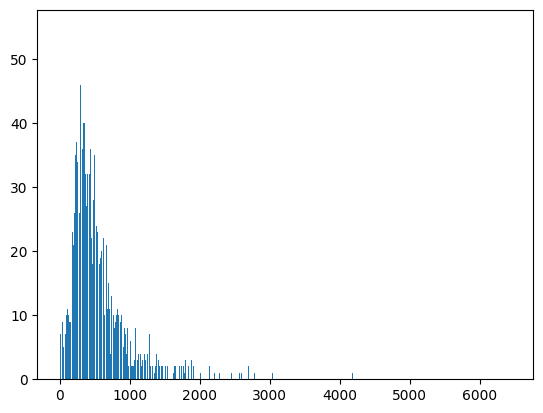

In [ ]:
import matplotlib.pyplot as plt

plt.bar(x=clean_total_bedrooms.value_counts().index, height=clean_total_bedrooms.value_counts().values)
plt.show() # this clearly shows how much difference between the lowest and highest values.

In [20]:
# Let's Start with getting Q1 & Q3:
q1 = california_housing.total_bedrooms.quantile(0.25) # Q1 is the first 25% (0.25) of data. 
q3 = california_housing.total_bedrooms.quantile(0.75) # Q3 is the first 75% (0.75) of data. 

# calculate the inter-quartile range: IQR = Q3 - Q1
iqr = q3 - q1

# calculate the upper & lower bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# let's check their values
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 296.0, Q3: 647.0, IQR: 351.0
Lower Bound: -230.5, Upper Bound: 1173.5


In [28]:
bedrooms = california_housing.total_bedrooms

outliers = bedrooms[(bedrooms < lower_bound) | (bedrooms > upper_bound)]
print(f"Identified Outliers:\n{len(outliers)}\n")

bedrooms_within_range = bedrooms[~((bedrooms < lower_bound) | (bedrooms > upper_bound))]
print(f"Without Outliers:\n{len(bedrooms_within_range)}")

Identified Outliers:
1271

Without Outliers:
19369


In [27]:
# Now let's Calculate the correct mean:
correct_mean = bedrooms_within_range.mean()

incorrect_mean = california_housing.total_bedrooms.mean()

# compare it with the incorrect mean:
print(f"Correct mean: {correct_mean}, Incorrect mean: {incorrect_mean}")

Correct mean: 458.0337125561006, Incorrect mean: 537.8705525375618


In [29]:
# Use the ".fillna()" function to fill missing values, use "inplace=True" so we don't have to assign again.
california_housing.total_bedrooms.fillna(correct_mean, inplace=True)

california_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [34]:
colors = {"colors":["Blue", "Red", "Green", "Blue", "Blue", "Green", "Red"]} # let's define a dataset with one column that has string values. 
colors_column = pd.Series(colors['colors']) # turn it into a 'pd.Series' object.
colors_column

0     Blue
1      Red
2    Green
3     Blue
4     Blue
5    Green
6      Red
dtype: object

In [ ]:
one_hot_encoded_colors = pd.get_dummies(colors_column) # Use the "pd.get_dummies" function to one-hot encode columns
one_hot_encoded_colors # Note: each value now is a column, and their values are either true or false (1 or 0).

,Blue,Green,Red
0,True,False,False
1,False,False,True
2,False,True,False
3,True,False,False
4,True,False,False
5,False,True,False
6,False,False,True


In [36]:
len(california_housing.ocean_proximity.unique()) # calculate the number of values in the column

5

In [ ]:
# We need to get the column, then remove it so there is no duplication and strings in the dataframe 
ocean_proximity = california_housing.pop('ocean_proximity') # '.pop()' deletes the column and returns it

one_hot_encoded_ocean_proximity = pd.get_dummies(ocean_proximity) # get the one-hot encoded version

one_hot_encoded_ocean_proximity.head()

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,True,False
3,False,False,False,True,False
4,False,False,False,True,False


In [ ]:
# "pd.concat" takes a list of dataframes and joins them into one single dataframe
# passing 'axis=1' means to join the columns together, passing 'axis=0' means to put the rows after each other
cleaned_california_housing = pd.concat([california_housing, one_hot_encoded_ocean_proximity], axis=1)
cleaned_california_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,False,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,False,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,False,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,False,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,False,False,False,True,False


In [51]:
y = cleaned_california_housing.pop("median_house_value") # The median price is what we want to predict so we remove it
X = cleaned_california_housing # The rest of the columns are features we will use.

X.shape, y.shape

((20640, 13), (20640,))

In [52]:
from sklearn.linear_model import LinearRegression, LogisticRegression # you can expriment with the logistic model if you want.

model = LinearRegression()

In [53]:
from sklearn.model_selection import train_test_split # the function is imported from the "model_selection" module

# splits both X & y into train & test, generating four arrays. Note: the ordering is as shown and doesn't change.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) 

print(f"Train dataset shapes: {X_train.shape, y_train.shape}") 
print(f"Test dataset shapes: {X_test.shape, y_test.shape}") 

Train dataset shapes: ((16512, 13), (16512,))
Test dataset shapes: ((4128, 13), (4128,))


In [54]:
model.fit(X_train, y_train) # simply call '.fit()' with the X input and y output

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
from sklearn.metrics import mean_absolute_error # import the funcion from the 'metrics' module.

# the mean absolute error is defined like:
# mae_score = | real_value - predicted_value |
# this is run across all instances and then an average is taken.

# let's get the model's prediction on the test data via the '.predict()' method which takes only the input data
y_pred = model.predict(X_test)

# then we pass the predicted values to function to get a score of how on average the model is off by.
# Note: the order of passing the values is required to be the real values first then the predicted.
mae_score = mean_absolute_error(y_test, y_pred) 
mae_score # by how much is our model off?

50162.1958766347

In [57]:
from sklearn.metrics import mean_squared_error

# the mean squared error is defined like:
# mse_score = ( real_value - predicted_value ) ** 2
# this is run across all instances and then an average is taken.

# we will use the previous prediction.
# Note: the order of passing the values is required to be the real values first then the predicted.
mse_score = mean_squared_error(y_test, y_pred)
mse_score # not really human understandable but is a good metric for outlier detection. 

4688306714.242042